In [1]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D


In [5]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

In [8]:
x, y = make_moons(100, noise = 0.25, random_state = 2)

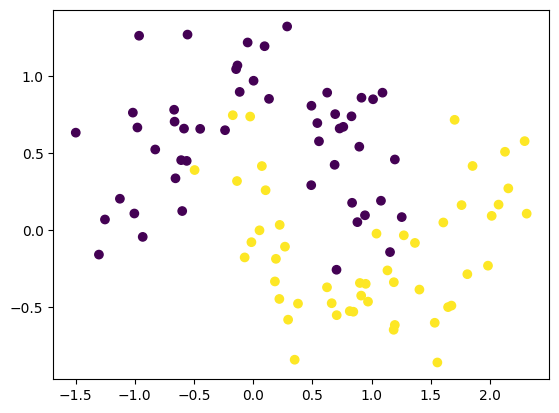

In [21]:
plt.scatter(x[:,0],x[:,1], c= y )     # c= y is passed for the y variable that is the class labels
# the plot is likee for a particular (x1,x2) the label is 0 or 1

In [20]:
np.unique(y)

array([0, 1])

In [32]:
model1 = Sequential()
model1.add(Dense(128, input_dim = 2, activation = "relu"))
model1.add(Dense(128, activation = "relu"))
model1.add(Dense(1, activation = "sigmoid"))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model1.compile(loss = "binary_crossentropy", optimizer = "adam", metrics = ["accuracy"])

In [35]:
history = model1.fit(x,y.astype(int), epochs = 500, validation_split = 0.2)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.5500 - loss: 0.6817 - val_accuracy: 0.7500 - val_loss: 0.6530
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7250 - loss: 0.6405 - val_accuracy: 0.8000 - val_loss: 0.6109
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7000 - loss: 0.6071 - val_accuracy: 0.8500 - val_loss: 0.5720
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7125 - loss: 0.5772 - val_accuracy: 0.8500 - val_loss: 0.5368
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7250 - loss: 0.5516 - val_accuracy: 0.8500 - val_loss: 0.5030
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7500 - loss: 0.5273 - val_accuracy: 0.8500 - val_loss: 0.4724
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7625 - loss: 0.5061 - val_accuracy: 0.8500 - val_loss: 0.4420
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7875 - loss: 0.4876 - val_accuracy: 0.9000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 804us/step


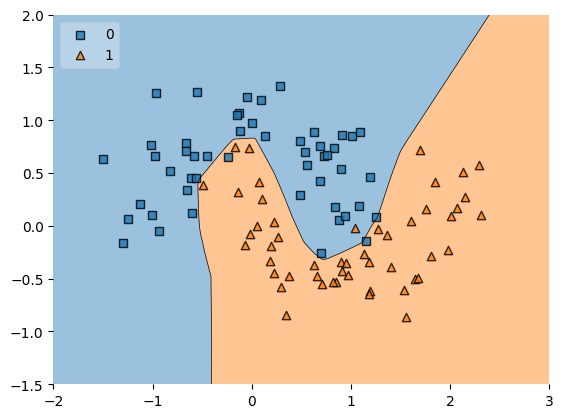

In [36]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x, y.astype('int'), clf=model1, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

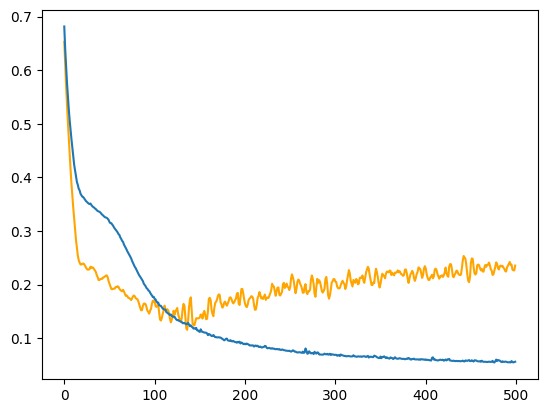

In [39]:
plt.plot(history.history["val_loss"], color = "orange")
plt.plot(history.history["loss"])

We can clearly see the gap between training loss and validation loss which shows that the model is overfitting

## Regularization

In [40]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(128, activation="relu",kernel_regularizer=tensorflow.keras.regularizers.l2(0.03)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model2.compile(loss='binary_crossentropy', optimizer="adam", metrics=['accuracy'])

In [46]:
history2 = model2.fit(x, y, epochs=500, validation_split = 0.2)

Epoch 1/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.8750 - loss: 0.3865 - val_accuracy: 1.0000 - val_loss: 0.3237
Epoch 2/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9125 - loss: 0.3534 - val_accuracy: 1.0000 - val_loss: 0.2809
Epoch 3/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9000 - loss: 0.3703 - val_accuracy: 1.0000 - val_loss: 0.2778
Epoch 4/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9000 - loss: 0.3568 - val_accuracy: 1.0000 - val_loss: 0.3047
Epoch 5/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9125 - loss: 0.3672 - val_accuracy: 0.9000 - val_loss: 0.3420
Epoch 6/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9125 - loss: 0.3603 - val_accuracy: 0.9000 - val_loss: 0.3166
Epoch 7/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9125 - loss: 0.3608 - val_accuracy: 1.0000 - val_loss: 0.2893
Epoch 8/500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9125 - loss: 0.3556 - val_accuracy: 1.0000 - val_loss:

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 8s 848us/step


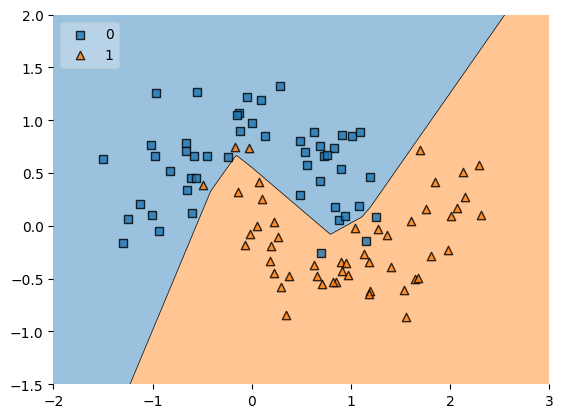

In [47]:
plot_decision_regions(x, y.astype('int'), clf=model2, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

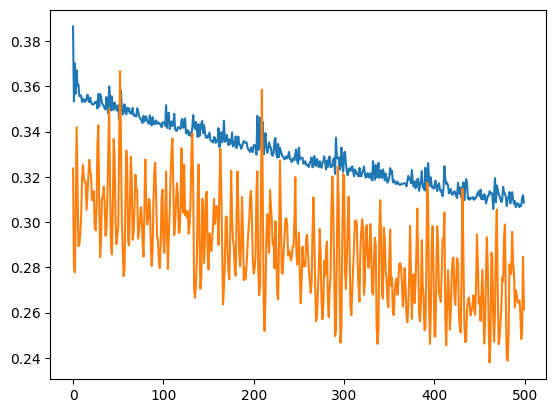

In [48]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])